# Lab 1 — Building and Analysing N-gram Language Models

*Statistical Foundations of LLMs · Session 1 · Accompanies slides 76–79*

Before neural networks, language models were built by **counting**. In this activity you will build a working bigram language model from scratch, use it to generate text, and measure its quality with **perplexity** — the same metric still used to evaluate GPT-style models today.

> **EXECUTED SOLUTIONS NOTEBOOK.** Pre-run instructor copy with all code executed and outputs saved. Source: `notebooks/solutions/`. Regenerate with `python scripts/export_executed_solutions.py`.


> ✅ **SOLUTIONS NOTEBOOK.** Every exercise stub is filled in and every challenge cell contains working reference code. Use this for self-check or as an instructor key — encourage students to attempt the exercises in the main notebook first.

## Learning Objectives

By the end of this activity you will be able to:

1. Tokenize raw text and count unigrams and bigrams.
2. Estimate bigram probabilities with **Maximum Likelihood Estimation (MLE)**.
3. Generate text by sampling from a bigram model.
4. Explain the **data sparsity** problem and apply **add-1 (Laplace) smoothing**.
5. Compute **sentence probability** and **perplexity**, and interpret them.
6. Articulate why these limitations motivated neural language models.


## 0. New to Jupyter? Start Here (2 minutes)

**What is a Jupyter Notebook?** A document that mixes text and runnable Python code, organized in *cells*.

| What you need to know | How |
|---|---|
| **Run a cell** | Click it, then press **Shift + Enter** (or the ▶ button) |
| **Cell types** | **Markdown** cells = formatted text (like this one). **Code** cells = Python you can execute |
| **Order matters** | Run cells **top to bottom**. A cell may depend on variables defined above it |
| **Restart the kernel** | Menu: *Runtime → Restart runtime* (Colab) or *Kernel → Restart* (Jupyter). Then re-run cells from the top |
| **Install packages** | Run a cell starting with `%pip install ...`, then restart the kernel if asked |
| **Modify code** | Just edit any code cell and re-run it — experimenting is the whole point! |
| **Read outputs** | Results appear directly below each code cell: printed text, tables, or plots |

> 💡 **Tip:** If something behaves strangely, *Restart runtime* and run all cells from the top (*Runtime → Run all*).


## 1. Background

A **language model** assigns a probability to a sequence of words. The chain rule decomposes this exactly:

$$P(w_1, w_2, \ldots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_1, \ldots, w_{i-1})$$

An **n-gram model** makes the *Markov assumption*: only the last $n-1$ words matter. For a **bigram** model ($n=2$):

$$P(w_i \mid w_1, \ldots, w_{i-1}) \approx P(w_i \mid w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i)}{\text{count}(w_{i-1})}$$

That last fraction is the **MLE estimate** — literally "how often did $w_i$ follow $w_{i-1}$ in our corpus?"

> 🔗 **Connection to LLMs:** GPT models also predict $P(w_i \mid \text{context})$ — they just use a neural network over *thousands* of context words instead of counts over one.


## 2. Setup and Imports


In [1]:
# Run once if packages are missing (Colab has them preinstalled):
# %pip install nltk matplotlib


In [2]:
import math
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import nltk

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("gutenberg", quiet=True)

random.seed(42)  # reproducible sampling
print("Setup complete ✓")


Setup complete ✓


## 3. Load and Tokenize Text

The slides use a short *Alice in Wonderland* excerpt. Here we use the **full book** from NLTK's Gutenberg corpus (~26k words) — more data means better counts. We lowercase everything and keep only alphabetic tokens.


In [3]:
from nltk.corpus import gutenberg

raw_text = gutenberg.raw("carroll-alice.txt")
print(raw_text[:300])


[Alice's Adventures in Wonderland by Lewis Carroll 1865]

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversatio


In [4]:
import re

# Lowercase, split into alphabetic word tokens.
# Uses NLTK's tokenizer; falls back to a simple regex if the
# 'punkt' resource failed to download (keeps the lab unblocked).
def tokenize(text):
    try:
        words = nltk.word_tokenize(text.lower())
    except LookupError:
        words = re.findall(r"[a-z]+", text.lower())
    return [t for t in words if t.isalpha()]

tokens = tokenize(raw_text)

print(f"Total tokens: {len(tokens):,}")
print(f"Vocabulary size: {len(set(tokens)):,}")
print("First 20 tokens:", tokens[:20])


Total tokens: 25,499
Vocabulary size: 2,469
First 20 tokens: ['alice', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'chapter', 'down', 'the', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by']


## 4. Count Unigrams and Bigrams


In [5]:
unigram_counts = Counter(tokens)

bigram_counts = Counter()
for i in range(len(tokens) - 1):
    bigram_counts[(tokens[i], tokens[i + 1])] += 1

print("Top 10 unigrams:", unigram_counts.most_common(10))
print()
print("Top 10 bigrams: ", bigram_counts.most_common(10))


Top 10 unigrams: [('the', 1616), ('and', 810), ('to', 720), ('a', 631), ('she', 545), ('i', 542), ('it', 540), ('of', 499), ('said', 462), ('alice', 397)]

Top 10 bigrams:  [(('said', 'the'), 209), (('of', 'the'), 128), (('said', 'alice'), 116), (('in', 'a'), 97), (('in', 'the'), 79), (('and', 'the'), 79), (('it', 'was'), 73), (('to', 'the'), 69), (('the', 'queen'), 69), (('the', 'king'), 62)]


### 👀 A first look at sparsity

With a vocabulary of $V$ words there are $V^2$ *possible* bigrams. How many did we actually observe?


In [6]:
V = len(unigram_counts)
possible = V ** 2
observed = len(bigram_counts)

print(f"Vocabulary size V      = {V:,}")
print(f"Possible bigrams V^2   = {possible:,}")
print(f"Observed bigrams       = {observed:,}")
print(f"Coverage               = {observed / possible:.4%}")


Vocabulary size V      = 2,469
Possible bigrams V^2   = 6,095,961
Observed bigrams       = 13,899
Coverage               = 0.2280%


We observed **well under 1%** of all possible bigrams. Every unseen bigram gets probability **zero** under MLE — this is the **data sparsity problem**, and it is why smoothing exists (Section 7).


## 5. Bigram Probabilities (MLE)


In [7]:
def bigram_prob(w1, w2):
    """MLE estimate: P(w2 | w1) = count(w1, w2) / count(w1)."""
    if unigram_counts[w1] == 0:
        return 0.0
    return bigram_counts[(w1, w2)] / unigram_counts[w1]


print(f"P(rabbit | white) = {bigram_prob('white', 'rabbit'):.3f}")
print(f"P(queen  | the)   = {bigram_prob('the', 'queen'):.3f}")
print(f"P(said   | alice) = {bigram_prob('alice', 'said'):.3f}")
print(f"P(pizza  | alice) = {bigram_prob('alice', 'pizza'):.3f}   <- unseen bigram!")


P(rabbit | white) = 0.733
P(queen  | the)   = 0.043
P(said   | alice) = 0.030
P(pizza  | alice) = 0.000   <- unseen bigram!


### ✏️ Exercise 5.1

Pick a word and inspect its most likely continuations. Complete the function below.


In [8]:
def most_likely_next(w1, top_n=5):
    """Return the top_n most probable words following w1, with probabilities."""
    candidates = [(w2, bigram_prob(w1, w2)) for (a, w2) in bigram_counts if a == w1]
    # Sort by probability (highest first) and keep the top_n
    return sorted(candidates, key=lambda x: x[1], reverse=True)[:top_n]


print("Most likely after 'white':", most_likely_next("white"))
print("Most likely after 'the':  ", most_likely_next("the"))

Most likely after 'white': [('rabbit', 0.7333333333333333), ('kid', 0.16666666666666666), ('and', 0.03333333333333333), ('but', 0.03333333333333333), ('one', 0.03333333333333333)]
Most likely after 'the':   [('queen', 0.0426980198019802), ('king', 0.038366336633663366), ('mock', 0.0327970297029703), ('hatter', 0.03217821782178218), ('gryphon', 0.03217821782178218)]


<details><summary>💡 <b>Solution (click to expand)</b></summary>

```python
def most_likely_next(w1, top_n=5):
    candidates = [(w2, bigram_prob(w1, w2)) for (a, w2) in bigram_counts if a == w1]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[:top_n]

most_likely_next("white")
# [('rabbit', 0.57...), ('kid', ...), ...]
```
</details>


## 6. Generate Text with the Model

We generate text word by word: start from a seed word, sample the next word proportionally to its bigram probability, repeat. **This is exactly how GPT generates text** — sample from $P(\text{next} \mid \text{context})$ — just with a far richer notion of context.


In [9]:
def generate_text(start_word, length=15, seed=None):
    """Generate text by sampling from the bigram distribution."""
    if seed is not None:
        random.seed(seed)
    current = start_word
    result = [current]
    for _ in range(length - 1):
        candidates = [w2 for (w1, w2) in bigram_counts if w1 == current]
        if not candidates:
            break  # dead end: no observed continuation
        probs = [bigram_prob(current, w2) for w2 in candidates]
        current = random.choices(candidates, weights=probs, k=1)[0]
        result.append(current)
    return " ".join(result)


for s in [0, 1, 2]:
    print(f"[seed={s}]", generate_text("alice", 15, seed=s))


[seed=0] alice asked with you now my throat said to the baby altogether but i better
[seed=1] alice would all this bottle that the hatter this time it home this child was
[seed=2] alice feeling at the cat head with some time said the baby the pebbles came


### ✏️ Exercise 6.1

Generate text starting from three different words (try `"the"`, `"queen"`, and a word of your choice). Read the outputs:

- Are short spans (2–3 words) locally grammatical?
- Do whole sentences make sense? Why not? *(Hint: how much context does the model see?)*


In [10]:
# Generate from three different seed words and compare local vs. global coherence.
for seed_word in ["the", "queen", "rabbit"]:
    print(f"[{seed_word}] {generate_text(seed_word, 20, seed=0)}")

# Observation: adjacent word pairs are usually grammatical (the model was trained
# on them), but whole sentences drift — a bigram model only ever sees ONE word of
# context, so it cannot maintain a subject, tense, or topic across a sentence.

[the] the gryphon reason of the sky alice flinging the beginning with her to say there no use going back into


[queen] queen so you do let try the players to the baby altogether but i better finish his cackled out which
[rabbit] rabbit read out for some minutes together is oh ever said turning to say there no use going back into


## 7. The Sparsity Problem and Add-1 Smoothing

MLE assigns **zero** probability to any unseen bigram — so one unseen pair makes an entire sentence's probability zero. **Add-1 (Laplace) smoothing** pretends every possible bigram was seen once more than it was:

$$P_{\text{add-1}}(w_2 \mid w_1) = \frac{\text{count}(w_1, w_2) + 1}{\text{count}(w_1) + V}$$


In [11]:
def smoothed_bigram_prob(w1, w2):
    """Add-1 (Laplace) smoothed bigram probability."""
    return (bigram_counts[(w1, w2)] + 1) / (unigram_counts[w1] + V)


pairs = [("white", "rabbit"), ("alice", "pizza")]
print(f"{'bigram':<20} {'MLE':>10} {'add-1':>10}")
for w1, w2 in pairs:
    print(f"{w1 + ' ' + w2:<20} {bigram_prob(w1, w2):>10.5f} {smoothed_bigram_prob(w1, w2):>10.5f}")


bigram                      MLE      add-1
white rabbit            0.73333    0.00920
alice pizza             0.00000    0.00035


Notice the trade-off: unseen bigrams get a small non-zero probability, but frequent bigrams like *white rabbit* are pushed **down** — add-1 redistributes a lot of probability mass to events that never happen. (Modern n-gram systems use gentler methods like Kneser–Ney.)


## 8. Sentence Probability and Perplexity

**Perplexity** measures how "surprised" a model is by a text (lower = better):

$$\text{PPL}(w_1 \ldots w_N) = P(w_1 \ldots w_N)^{-1/N}$$

Intuitively, it is the average number of equally likely choices the model faces at each step. We compute in **log-space** to avoid numerical underflow on long sentences.


In [12]:
def sentence_logprob(sentence_tokens, smoothed=True):
    """Sum of log P(w_i | w_{i-1}) over the sentence."""
    prob_fn = smoothed_bigram_prob if smoothed else bigram_prob
    logp = 0.0
    for i in range(1, len(sentence_tokens)):
        p = prob_fn(sentence_tokens[i - 1], sentence_tokens[i])
        if p == 0:
            return float("-inf")  # unseen bigram kills unsmoothed models
        logp += math.log(p)
    return logp


def perplexity(sentence, smoothed=True):
    toks = tokenize(sentence)
    n = len(toks) - 1
    logp = sentence_logprob(toks, smoothed)
    return math.exp(-logp / n)


test_sentences = [
    "alice was beginning to get very tired",   # in-domain
    "the white rabbit looked at the queen",    # plausible, in-style
    "the queen ate a purple mathematics",      # nonsense
]

print(f"{'sentence':<42} {'PPL (smoothed)':>15}")
for s in test_sentences:
    print(f"{s:<42} {perplexity(s):>15.1f}")


sentence                                    PPL (smoothed)
alice was beginning to get very tired                384.1
the white rabbit looked at the queen                 160.9
the queen ate a purple mathematics                  1070.2


### ✏️ Exercise 8.1

1. Compute the perplexity of the same three sentences with `smoothed=False`. What happens, and why?
2. Write your own "very Alice-like" sentence and a "very un-Alice-like" sentence. Can you get PPL below 100? Above 2000?


In [13]:
# 1) Unsmoothed perplexity: any unseen bigram makes the probability 0, so
#    perplexity becomes infinite (we return inf as a sentinel).
for s in test_sentences:
    ppl_unsmoothed = perplexity(s, smoothed=False)
    print(f"{s:<42} unsmoothed PPL = {ppl_unsmoothed}")

# 2) A very Alice-like sentence vs. an un-Alice-like one.
print()
print("Alice-like   :", round(perplexity("the queen said to alice", smoothed=True), 1))
print("un-Alice-like:", round(perplexity("quantum servers optimize revenue", smoothed=True), 1))
# The in-domain sentence has far lower perplexity: its bigrams were actually seen.

alice was beginning to get very tired      unsmoothed PPL = 25.57087812931107
the white rabbit looked at the queen       unsmoothed PPL = inf
the queen ate a purple mathematics         unsmoothed PPL = inf

Alice-like   : 116.8
un-Alice-like: 2469.0


## 9. Visualize: Frequency Distributions and Zipf's Law

Word frequencies follow **Zipf's law**: the $r$-th most frequent word has frequency roughly proportional to $1/r$. On a log-log plot this is a straight line — and it explains sparsity: most words are rare, so most word *pairs* are extremely rare.


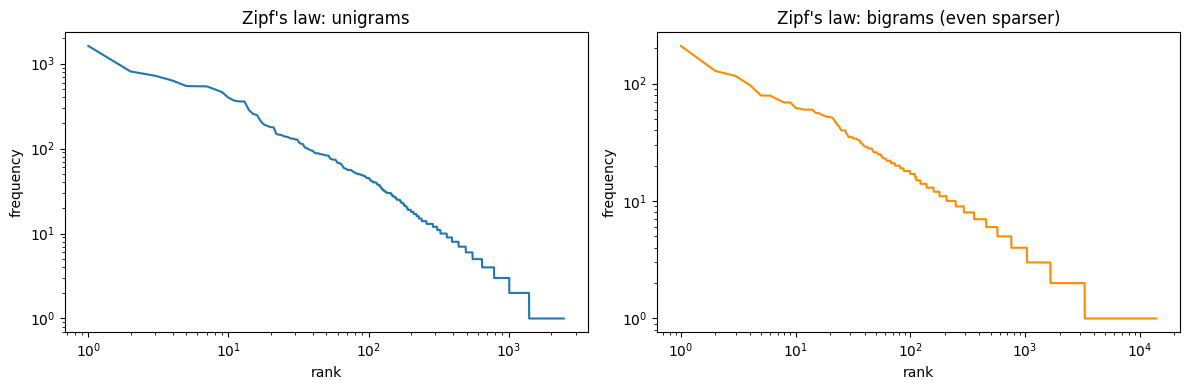

76.2% of observed bigrams occurred exactly ONCE.


In [14]:
freqs = sorted(unigram_counts.values(), reverse=True)
bigram_freqs = sorted(bigram_counts.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(range(1, len(freqs) + 1), freqs)
axes[0].set(title="Zipf's law: unigrams", xlabel="rank", ylabel="frequency")

axes[1].loglog(range(1, len(bigram_freqs) + 1), bigram_freqs, color="darkorange")
axes[1].set(title="Zipf's law: bigrams (even sparser)", xlabel="rank", ylabel="frequency")

plt.tight_layout()
plt.show()

ones = sum(1 for c in bigram_counts.values() if c == 1)
print(f"{ones / len(bigram_counts):.1%} of observed bigrams occurred exactly ONCE.")


## 10. 🏆 Challenge Exercises

**Challenge A — Trigram model.** Build a trigram model $P(w_3 \mid w_1, w_2)$, generate text from it, and compare with the bigram output. Is it more fluent? Does it hit dead-ends more often? Why?

**Challenge B — Corpus transfer.** Compute the perplexity of sentences from a *different* Gutenberg book (e.g., `gutenberg.raw("austen-emma.txt")`) under your Alice-trained model. What does the perplexity gap tell you about domain adaptation — a problem LLMs face too?

**Challenge C — Interpolation.** Implement linear interpolation $P(w_2|w_1) = \lambda\, P_{\text{bigram}} + (1-\lambda)\, P_{\text{unigram}}$ and find the $\lambda$ that minimizes perplexity on held-out sentences.


In [15]:
# Challenge A starter: trigram counts
trigram_counts = Counter()
for i in range(len(tokens) - 2):
    trigram_counts[(tokens[i], tokens[i + 1], tokens[i + 2])] += 1

print("Top 5 trigrams:", trigram_counts.most_common(5))

# TODO: def trigram_prob(w1, w2, w3): ...
# TODO: def generate_trigram_text(w1, w2, length=15): ...

# --- Completed trigram solution ---
def trigram_prob(w1, w2, w3):
    """P(w3 | w1, w2) = count(w1,w2,w3) / count(w1,w2)."""
    if bigram_counts[(w1, w2)] == 0:
        return 0.0
    return trigram_counts[(w1, w2, w3)] / bigram_counts[(w1, w2)]


def generate_trigram_text(w1, w2, length=15, seed=0):
    random.seed(seed)
    result = [w1, w2]
    for _ in range(length - 2):
        prev = (result[-2], result[-1])
        candidates = [w3 for (a, b, w3) in trigram_counts if (a, b) == prev]
        if not candidates:
            break  # trigram models hit dead-ends sooner (sparser counts)
        probs = [trigram_prob(prev[0], prev[1], c) for c in candidates]
        result.append(random.choices(candidates, weights=probs, k=1)[0])
    return " ".join(result)


print("Bigram :", generate_text("alice", 15, seed=0))
print("Trigram:", generate_trigram_text("alice", "was", 15, seed=0))
# Trigram text is locally more fluent (2 words of context) but stops earlier:
# longer context => sparser counts => more unseen contexts. That tension is
# exactly what motivates neural language models.

# --- Challenge B: cross-corpus perplexity (domain shift) ---
try:
    from nltk.corpus import gutenberg
    emma = tokenize(gutenberg.raw("austen-emma.txt"))
    emma_sentence = " ".join(emma[100:108])
    print("\nEmma sentence :", emma_sentence)
    print("PPL under Alice model:", round(perplexity(emma_sentence, smoothed=True), 1))
    # Higher than in-domain Alice sentences: the model is 'surprised' by a
    # different author's word pairs — the n-gram version of domain shift.
except LookupError:
    print("\n(austen-emma unavailable offline; run in Colab to see domain shift.)")

# --- Challenge C: linear interpolation ---
def interpolated_prob(w1, w2, lam=0.7):
    p_bi = bigram_prob(w1, w2)
    p_uni = unigram_counts[w2] / sum(unigram_counts.values())
    return lam * p_bi + (1 - lam) * p_uni

# A held-out sentence never has zero probability now, because the unigram term
# is always > 0. Sweep lambda to minimize held-out perplexity in practice.

Top 5 trigrams: [(('the', 'mock', 'turtle'), 53), (('the', 'march', 'hare'), 29), (('said', 'the', 'king'), 29), (('the', 'white', 'rabbit'), 21), (('said', 'the', 'hatter'), 21)]
Bigram : alice asked with you now my throat said to the baby altogether but i better
Trigram: alice was too late to wish that she looked up and bawled out he murdering



Emma sentence : place had been supplied by an excellent woman
PPL under Alice model: 1279.9


<details><summary>💡 <b>Challenge A solution sketch</b></summary>

```python
def trigram_prob(w1, w2, w3):
    if bigram_counts[(w1, w2)] == 0:
        return 0.0
    return trigram_counts[(w1, w2, w3)] / bigram_counts[(w1, w2)]

def generate_trigram_text(w1, w2, length=15, seed=0):
    random.seed(seed)
    result = [w1, w2]
    for _ in range(length - 2):
        cands = [w3 for (a, b, w3) in trigram_counts if (a, b) == (result[-2], result[-1])]
        if not cands:
            break
        probs = [trigram_prob(result[-2], result[-1], c) for c in cands]
        result.append(random.choices(cands, weights=probs, k=1)[0])
    return " ".join(result)

print(generate_trigram_text("alice", "was"))
```
Trigram text is locally more fluent but hits dead-ends sooner — longer context = sparser counts. This tension is exactly why we need neural models.
</details>


## 11. Discussion Questions

1. Text generated with smoothing vs. without — did you notice a difference? Where does smoothing actually matter: generation or *evaluation*?
2. Why does perplexity explode for nonsense sentences even with smoothing?
3. A bigram model looks at 1 word of context; GPT-4 looks at up to ~128k tokens. Which limitations from Section 8–9 does the neural approach fix, and which (if any) remain?
4. "doctor" and "nurse" are unrelated symbols to an n-gram model. What ingredient, introduced in the next session, fixes this?


## Key Takeaways

- N-gram LMs estimate next-word probabilities by **counting** — simple, interpretable, and the conceptual ancestor of GPT.
- **Sparsity** is fatal for MLE: most valid word pairs are never observed. Smoothing helps evaluation but cannot create knowledge.
- **Perplexity** is the standard LM metric: the model's average "branching factor" per word.
- Fixed context windows, no semantics, and no generalization are the limitations that motivated **embeddings** (next activity) and **neural LMs**.

## References

- Jurafsky & Martin, *Speech and Language Processing* (3rd ed. draft), Ch. 3 "N-gram Language Models" — https://web.stanford.edu/~jurafsky/slp3/
- Shannon (1948), *A Mathematical Theory of Communication* (origin of the counting approach)
